In [72]:
import numpy as np
import torch
from collections import defaultdict
from sklearn.model_selection import KFold
import os
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, classification_report, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
os.chdir("/mnt/sunxh/sunxh/wattmamba")  
print(os.getcwd())
from model.model import WaveCrossMamba,AnomalyDetectionModel
from utils.dataloader import SupervisedDataset,load_data_supervised
from train_test.anomaly_detection import test_model
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()  
print("测试过程。")

/mnt/sunxh/sunxh/wattmamba
测试过程。


In [73]:
import matplotlib.pyplot as plt
def plot_roc_pr_curves(fpr, tpr, roc_auc, precision, recall, pr_auc, title=""):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve {title}')
    plt.legend(loc="lower right")
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='red', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve {title}')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()

In [74]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc, roc_curve
import numpy as np
import torch
from collections import defaultdict
from sklearn.model_selection import KFold
import os
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, classification_report, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
os.chdir("/mnt/sunxh/sunxh/wattmamba/")  
print(os.getcwd())
from model.model import WaveCrossMamba,AnomalyDetectionModel
from utils.dataloader import SupervisedDataset,load_data_supervised
from train_test.anomaly_detection import test_model
import os
import random
kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}

def load_data_supervised(data_files, data_length, validation_split=0.0, pos_neg_ratio=0.5):
    X = []
    Y = []
    file_data_counts = {}
    total_data_count = 0
    positive_samples = []
    negative_samples = []  


    for file, label in data_files:
        with open(file) as f:
            count = 0
            for line in f:
                line = line.rstrip()
                items = line.split("\t")
                if line.startswith("read_id"):
                    continue
                signals = "|".join(items[9:14]).split("|")
                signal = np.array([float(signal) for signal in signals], dtype=np.float32)
                kmer = items[3]
                kmer = np.array([kmer_encode_dic[base] for base in kmer], dtype=np.int32)
                mean = np.array([float(item) for item in items[4].split("|")], dtype=np.float32)
                std = np.array([float(item) for item in items[5].split("|")], dtype=np.float32)
                intense = np.array([float(item) for item in items[6].split("|")], dtype=np.float32)
                dwell = np.array([float(item) for item in items[7].split("|")], dtype=np.float32) / 200.0
                base_quality = np.array([float(item) for item in items[8].split("|")], dtype=np.float32)
                base_quality = base_quality / 40.0

                x = [signal, kmer, mean, std, intense, dwell, base_quality]
                if label == 1:
                    positive_samples.append((x, label))
                else:
                    negative_samples.append((x, label))

                count += 1
                if count >= data_length:
                    break
            
            file_data_counts[file] = count
            total_data_count += count


    total_samples = min(len(positive_samples) + len(negative_samples), data_length * len(data_files))
    num_pos_samples = int(total_samples * pos_neg_ratio)
    num_neg_samples = total_samples - num_pos_samples


    positive_samples = random.sample(positive_samples, min(num_pos_samples, len(positive_samples)))
    negative_samples = random.sample(negative_samples, min(num_neg_samples, len(negative_samples)))


    combined = positive_samples + negative_samples
    random.shuffle(combined)


    X, Y = zip(*combined)

    for file, count in file_data_counts.items():
        print(f"文件 {file} 中加载了 {count} 条数据")

    num_samples = len(X)
    val_size = int(num_samples * validation_split)

    X_train = X[val_size:]
    Y_train = Y[val_size:]
    X_val = X[:val_size]
    Y_val = Y[:val_size]

    print(f"总数据量: {num_samples}")
    print(f"训练集大小: {len(X_train)}")
    print(f"验证集大小: {len(X_val)}")
    print(f"正样本数: {len(positive_samples)}, 负样本数: {len(negative_samples)}, 目标比例: {pos_neg_ratio:.2f}")

    return (X_train, Y_train), (X_val, Y_val)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def test_model(pretrain_model, model, test_loader, device):
    model.to(device)
    pretrain_model.to(device)
    all_labels = []
    all_preds = []
    all_probs = []

    model.eval()
    pretrain_model.eval()
    with torch.no_grad():
        for batch_idx, (data, rog, targets) in enumerate(test_loader):
            x, kmer, mean, std, intense, dwell, base_quality = data


            x = x.to(device)
            kmer = kmer.to(device)
            mean = mean.to(device)
            std = std.to(device)
            intense = intense.to(device)
            dwell = dwell.to(device)
            base_quality = base_quality.to(device)
            targets = targets.to(device)

            if targets.dtype != torch.long:
                targets = targets.long()
            x = x.unsqueeze(2)

            logits, ff = pretrain_model(x, kmer, mean, std, intense, dwell, base_quality)
            y_pred = model(logits).to(device)
            
            probs = torch.softmax(y_pred, dim=1).cpu().numpy()[:, 1]

            all_labels.extend(targets.cpu().numpy())
            all_preds.extend(np.argmax(y_pred.cpu().numpy(), axis=1))
            all_probs.extend(probs)
    

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)


    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()


    roc_auc = roc_auc_score(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall, precision)
    fpr_all, tpr_all, _ = roc_curve(all_labels, all_probs)


    min_len_roc = min(len(fpr_all), len(tpr_all))
    fpr_all, tpr_all = fpr_all[:min_len_roc], tpr_all[:min_len_roc]

    min_len_pr = min(len(precision), len(recall))
    precision, recall = precision[:min_len_pr], recall[:min_len_pr]


    f1_score = (2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) > 0 else 0
    precision_score = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_score = tp / (tp + fn) if (tp + fn) > 0 else 0
    tpr_value = tp / (tp + fn) if (tp + fn) > 0 else 0
    fnr_value = fn / (tp + fn) if (tp + fn) > 0 else 0
    print(f1_score)
    print(roc_auc,pr_auc)
    return fpr_all, tpr_all, precision, recall, roc_auc, pr_auc, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs



/mnt/sunxh/sunxh/wattmamba


In [75]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m6A_DRACH.test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_DRACH.test.tsv', 0)
]
data_length = int(4000)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Backdone_modbase-m6a-drach.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Classifier_modbase-m6a-drach.pth', map_location=device))
print("开始评估二分类异常检测模型...")
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m6A_DRACH.test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_DRACH.test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
开始评估二分类异常检测模型...
0.8926889714993804
0.9603993437500001 0.9597324672801709


In [76]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m6A_rep1.test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNANN.test.tsv', 0)
]
data_length = int(4000)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Backdone_modbase-m6a.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Classifier_modbase-m6a.pth', map_location=device))
print("开始评估二分类异常检测模型...")
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m6A_rep1.test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNANN.test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
开始评估二分类异常检测模型...
0.920316373509621
0.9829129062499999 0.9823498928013761


In [77]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/Inosine_rep1.test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNANN.test.tsv', 0)
]
data_length = int(4000)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Backdone_modbase-inosine512.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Classifier_modbase-inosine512.pth', map_location=device))
print("开始评估二分类异常检测模型...")
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/Inosine_rep1.test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNANN.test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
开始评估二分类异常检测模型...
0.9836729527907859
0.9990084375000001 0.9989373406757538


In [78]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/pseU_rep1.test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNTNN.test.tsv', 0)
]
data_length = int(4000)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Backdone_modbase-psU.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Classifier_modbase-psU.pth', map_location=device))
print("开始评估二分类异常检测模型...")
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/pseU_rep1.test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNTNN.test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
开始评估二分类异常检测模型...
0.9360678566907203
0.9853075625000001 0.9846358294252521


In [79]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m5C_rep1.test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNCNN.test.tsv', 0)
]
data_length = int(4000)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Backdone_modbase-m5c512.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Classifier_modbase-m5c512.pth', map_location=device))
print("开始评估二分类异常检测模型...")
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m5C_rep1.test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNCNN.test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
开始评估二分类异常检测模型...
0.9160928334608518
0.9751138437500002 0.975776283062465


In [80]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Arial'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_length = 4000

base_feat_dir = "/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature"
base_ckpt_dir = "/mnt/sunxh/sunxh/wattmamba/save_result/RNA004"

experiments = [
    {
        "name": "m6A",
        "data_files": [
            (f"{base_feat_dir}/m6A_rep1.test.tsv", 1),
            (f"{base_feat_dir}/control_rep1.NNANN.test.tsv", 0),
        ],
        "backbone_ckpt":   f"{base_ckpt_dir}/Backdone_modbase-m6a.pth",
        "classifier_ckpt": f"{base_ckpt_dir}/Classifier_modbase-m6a.pth",
    },
    {
        "name": "Inosine",
        "data_files": [
            (f"{base_feat_dir}/Inosine_rep1.test.tsv", 1),
            (f"{base_feat_dir}/control_rep1.NNANN.test.tsv", 0),
        ],
        "backbone_ckpt":   f"{base_ckpt_dir}/Backdone_modbase-inosine512.pth",
        "classifier_ckpt": f"{base_ckpt_dir}/Classifier_modbase-inosine512.pth",
    },
    {
        "name": "Ψ (pseU)",
        "data_files": [
            (f"{base_feat_dir}/pseU_rep1.test.tsv", 1),
            (f"{base_feat_dir}/control_rep1.NNTNN.test.tsv", 0),
        ],
        "backbone_ckpt":   f"{base_ckpt_dir}/Backdone_modbase-psU.pth",
        "classifier_ckpt": f"{base_ckpt_dir}/Classifier_modbase-psU.pth",
    },
    {
        "name": "m5C",
        "data_files": [
            (f"{base_feat_dir}/m5C_rep1.test.tsv", 1),
            (f"{base_feat_dir}/control_rep1.NNCNN.test.tsv", 0),
        ],
        "backbone_ckpt":   f"{base_ckpt_dir}/Backdone_modbase-m5c512.pth",
        "classifier_ckpt": f"{base_ckpt_dir}/Classifier_modbase-m5c512.pth",
    },
]

results = {}  # name -> dict

for exp in experiments:
    print(f"开始评估：{exp['name']}")

    (X_test, Y_test), _ = load_data_supervised(
        exp["data_files"], data_length, validation_split=0.0
    )

    test_dataset = SupervisedDataset(
        X_test, Y_test, augment=False, num_aug=1
    )
    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=2000,
        shuffle=False,
        num_workers=16,
        pin_memory=True
    )

    pretrained_feature_extractor = WaveCrossMamba(
        device=device, d_model=128
    ).to(device)
    fine_tune_model = AnomalyDetectionModel(
        feature_dim=128, num_classes=2
    ).to(device)

    pretrained_feature_extractor.load_state_dict(
        torch.load(exp["backbone_ckpt"], map_location=device)
    )
    fine_tune_model.load_state_dict(
        torch.load(exp["classifier_ckpt"], map_location=device)
    )

    (fpr_all, tpr_all,
     precision_all, recall_all,
     roc_auc_all, pr_auc_all,
     tn, fp, fn, tp,
     f1_sc, prec_sc, rec_sc,
     tpr_value, fnr_value,
     all_labels, all_preds, all_probs) = test_model(
        pretrained_feature_extractor,
        fine_tune_model,
        test_loader,
        device
    )

    results[exp["name"]] = {
        "fpr": fpr_all,
        "tpr": tpr_all,
        "precision_curve": precision_all,
        "recall_curve": recall_all,

        "roc_auc": roc_auc_all,
        "pr_auc": pr_auc_all,

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "f1": f1_sc,
        "prec": prec_sc,
        "rec": rec_sc,
        "tpr_value": tpr_value,
        "fnr_value": fnr_value,
    }
    
rows = []
for name, res in results.items():
    rows.append({
        "name": name,
        "roc_auc": res["roc_auc"],
        "pr_auc": res["pr_auc"],
        "tn": res["tn"],
        "fp": res["fp"],
        "fn": res["fn"],
        "tp": res["tp"],
        "f1": res["f1"],
        "precision": res["prec"],
        "recall": res["rec"],
        "tpr_at_thresh": res["tpr_value"],
        "fnr_at_thresh": res["fnr_value"],
    })
df_metrics = pd.DataFrame(rows)
out_csv = "/mnt/sunxh/sunxh/wattmamba/new_result/rna-modbase-metric.csv"
df_metrics.to_csv(out_csv, index=False)
print(f"ROC/PR summary 指标已保存到: {out_csv}")


开始评估：m6A
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m6A_rep1.test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNANN.test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
0.920316373509621
0.9829129062499999 0.9823498928013761
开始评估：Inosine
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/Inosine_rep1.test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNANN.test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
0.9836729527907859
0.9990084375000001 0.9989373406757538
开始评估：Ψ (pseU)
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/pseU_rep1.test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNTNN.test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
0.9360678566907203
0.9853075625000001 0.9846358294252521
开始评估：m5C
文件 /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m5C_rep1.test.tsv 中加载了 4000 条数据
文件 

多修饰 ROC+PR 联合图已保存到: /mnt/sunxh/sunxh/wattmamba/new_result/supfig11_rna-modbase-rocpr_panel.pdf


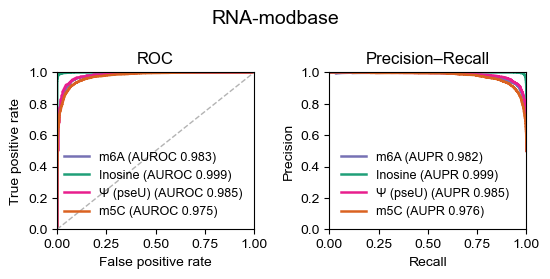

In [ ]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(5.6, 2.8))
plt.rcParams['font.family'] = 'Arial'
fig.suptitle("RNA-modbase", fontsize=14)

colors = [
    (118/255, 113/255, 180/255),
    (31/255, 159/255, 120/255),
    (232/255, 30/255, 141/255),
    (218/255, 98/255, 33/255),
]

plot_order = ["m6A", "Inosine", "Ψ (pseU)", "m5C"]

for color, name in zip(colors, plot_order):
    res = results[name]

    ax_roc.plot(
        res["fpr"], res["tpr"],
        linewidth=1.8,
        color=color,
        label=f"{name} (AUROC {res['roc_auc']:.3f})"
    )

    ax_pr.plot(
        res["recall_curve"], res["precision_curve"],
        linewidth=1.8,
        color=color,
        label=f"{name} (AUPR {res['pr_auc']:.3f})"
    )

ax_roc.plot([0, 1], [0, 1],
            linestyle="--", linewidth=1.0, color=(0.7, 0.7, 0.7))
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1)
ax_roc.set_title("ROC")

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_xlim(0, 1)
ax_pr.set_ylim(0, 1)
ax_pr.set_title("Precision–Recall")

ax_roc.legend(loc="lower right", frameon=False, fontsize=9)
ax_pr.legend(loc="lower left", frameon=False, fontsize=9)

plt.tight_layout()

out_png = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_rna-modbase-rocpr_panel.pdf"
fig.savefig(out_png, dpi=1200)
print(f"多修饰 ROC+PR 联合图已保存到: {out_png}")
plt.show()

Accuracy/Precision 柱状图已保存到: /mnt/sunxh/sunxh/wattmamba/new_result/supfig11_rna-modbase-acc_prec_bar.pdf


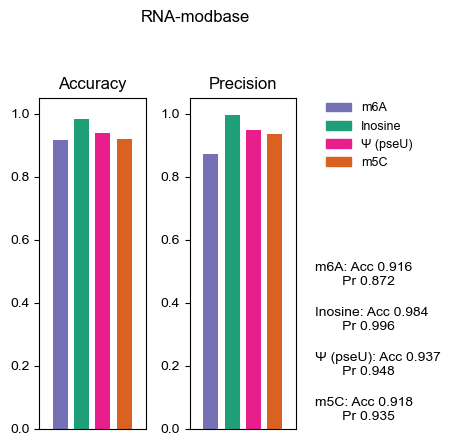

In [117]:
import numpy as np  
mods = ["m6A", "Inosine", "Ψ (pseU)", "m5C"]
colors = [
    (118/255, 113/255, 180/255),
    (31/255, 159/255, 120/255),  
    (232/255, 30/255, 141/255),  
    (218/255, 98/255, 33/255),
]
acc_values = []
prec_values = []
for name in mods:
    res = results[name]
    tn, fp, fn, tp = res["tn"], res["fp"], res["fn"], res["tp"]
    denom = tn + fp + fn + tp
    acc = (tp + tn) / denom if denom > 0 else np.nan
    acc_values.append(acc)
    prec_values.append(res["prec"])
gap = 0.001              
x = np.arange(len(mods)) * gap
bar_width = 0.7 * gap   
fig, (ax_acc, ax_prec) = plt.subplots(1, 2, figsize=(4, 4.5))
fig.suptitle("RNA-modbase", fontsize=12)
for i, (val, color) in enumerate(zip(acc_values, colors)):
    ax_acc.bar(x[i], val, width=bar_width, color=color)
ax_acc.set_ylim(0, 1.05)
ax_acc.set_xlim(x[0] - gap, x[-1] + gap)
ax_acc.set_ylabel("")
ax_acc.set_title("Accuracy")
ax_acc.set_xticks([])
ax_acc.set_xticklabels([])

for i, (val, color) in enumerate(zip(prec_values, colors)):
    ax_prec.bar(x[i], val, width=bar_width, color=color)
ax_prec.set_ylim(0, 1.05)
ax_prec.set_xlim(x[0] - gap, x[-1] + gap)
ax_prec.set_ylabel("")
ax_prec.set_title("Precision")
ax_prec.set_xticks([])
ax_prec.set_xticklabels([])
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
lines = []
for name, acc, prec in zip(mods, acc_values, prec_values):
    lines.append(f"{name}: Acc {acc:.3f}\n       Pr {prec:.3f}")

fig.legend(handles, mods,
           loc="upper left",
           bbox_to_anchor=(0.80, 0.80),
           frameon=False,
           fontsize=9)
x_text = 0.80  
y_start = 0.42  
line_gap = 0.1
for i, line in enumerate(lines):
    fig.text(
        x_text,
        y_start - i * line_gap,
        line,
        ha="left",
        va="top",
        fontsize=10
    )

plt.tight_layout(rect=[0, 0, 0.79, 0.93])
out_png_bar = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_rna-modbase-acc_prec_bar.pdf"
fig.savefig(out_png_bar, dpi=1200,bbox_inches="tight")
print(f"Accuracy/Precision 柱状图已保存到: {out_png_bar}")
plt.show()

In [109]:
plt.rcParams['font.family'] = 'Arial'


def parse_signal_field(s):
    """把 'a|b|c' 这种字符串解析成 float list."""
    if pd.isna(s):
        return []
    vals = []
    for x in str(s).split("|"):
        x = x.strip()
        if not x:
            continue
        try:
            vals.append(float(x))
        except ValueError:
            pass
    return vals


def pad_and_stack(list_of_lists):
    """不等长 list 补 NaN，堆成 2D array，shape = (n_reads, max_len)."""
    if len(list_of_lists) == 0:
        return np.zeros((0, 0), dtype=float)
    max_len = max(len(x) for x in list_of_lists)
    arr = np.full((len(list_of_lists), max_len), np.nan, dtype=float)
    for i, sig in enumerate(list_of_lists):
        L = len(sig)
        if L == 0:
            continue
        arr[i, :L] = sig
    return arr


def plot_motif_concat_signals(file_m6a, file_ctrl,
                              motif="GGACT", n=50,
                              out_png="/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_signal_GGACT_concat_m6A_vs_control.pdf"):

    seg_cols = ["sig_-2", "sig_-1", "sig_0", "sig_+1", "sig_+2"]

    def load_concat(path):
        df = pd.read_csv(path, sep="\t")
        df = df[df["5mer"] == motif].head(n).copy()
        concat_signals = []
        for _, row in df.iterrows():
            sig_all = []
            for c in seg_cols:
                sig_all.extend(parse_signal_field(row[c]))
            if len(sig_all) > 0:
                concat_signals.append(sig_all)
        return concat_signals

    concat_m6a   = load_concat(file_m6a)
    concat_ctrl  = load_concat(file_ctrl)

    all_signals = concat_m6a + concat_ctrl
    arr_all = pad_and_stack(all_signals)
    if arr_all.size == 0:
        print("没有找到任何满足条件的信号。")
        return

    L = arr_all.shape[1]

    n_m6a  = len(concat_m6a)
    n_ctrl = len(concat_ctrl)
    arr_m6a  = arr_all[:n_m6a]
    arr_ctrl = arr_all[n_m6a:n_m6a + n_ctrl]

    x = np.arange(L)
    mean_m6a  = np.nanmean(arr_m6a,  axis=0) if n_m6a  > 0 else np.full(L, np.nan)
    mean_ctrl = np.nanmean(arr_ctrl, axis=0) if n_ctrl > 0 else np.full(L, np.nan)

    fig, ax = plt.subplots(figsize=(5, 3))
    fig.suptitle(f"{motif} signal",fontsize=11)

    color_m6a  = (118/255, 113/255, 180/255)
    color_ctrl = (31/255, 159/255, 120/255)

    ax.plot(x, mean_m6a,  color=color_m6a,  linewidth=1.8, label="m6A")
    ax.plot(x, mean_ctrl, color=color_ctrl, linewidth=1.8, label="normalA")

    ax.set_xlabel("Concatenated position (sig_-2, sig_-1, sig_0, sig_+1, sig_+2)")
    ax.set_ylabel("Normalized signal")
    ax.set_xlim(0, L - 1)
    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    fig.savefig(out_png, dpi=300)
    print(f"拼接信号平均曲线已保存到: {out_png}")
    plt.show()


拼接信号平均曲线已保存到: /mnt/sunxh/sunxh/wattmamba/new_result/supfig11_signal_GGACT_concat_m6A_vs_control.pdf


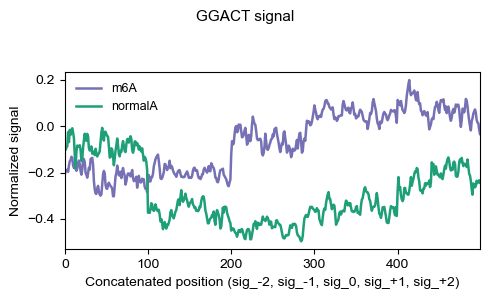

In [110]:
plot_motif_concat_signals(
    "/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m6A_rep1.tsv",
    "/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.tsv",
    motif="GGACT",
    n=30,
)

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'Arial'


def parse_pipe_floats(s, expected=None):
    """
    把 'a|b|c' 解析成 float list。
    expected: 如果给定，则长度不足时用 NaN 填充，多的截断。
    """
    if pd.isna(s):
        vals = []
    else:
        vals = []
        for x in str(s).split("|"):
            x = x.strip()
            if not x:
                continue
            try:
                vals.append(float(x))
            except ValueError:
                pass

    if expected is not None:
        if len(vals) < expected:
            vals = vals + [np.nan] * (expected - len(vals))
        else:
            vals = vals[:expected]
    return vals


def feature_from_row(row):
    """
    把一行 feature（m6A / m5C / control 等）转换为一个特征向量：
    - pos1
    - mean/std/median/length/base_qual 各 5 个元素
    - 每个 sig_* 段的 mean/std/median
    """
    feats = []

    feats.append(float(row["pos1"]))

    for col in ["mean", "std", "median", "length", "base_qual"]:
        vals = parse_pipe_floats(row[col], expected=5)
        feats.extend(vals)

    for col in ["sig_-2", "sig_-1", "sig_0", "sig_+1", "sig_+2"]:
        sig = parse_pipe_floats(row[col], expected=None)
        if len(sig) == 0:
            feats.extend([np.nan, np.nan, np.nan])
        else:
            sig = np.asarray(sig, dtype=float)
            feats.extend([
                float(np.nanmean(sig)),
                float(np.nanstd(sig)),
                float(np.nanmedian(sig)),
            ])

    return np.asarray(feats, dtype=float)


def build_feature_matrix(path, label, n_rows=30):
    """
    从一个 TSV 文件读取前 n_rows 行，转成特征矩阵 X 和标签列表 y。
    """
    df = pd.read_csv(path, sep="\t")
    df = df.head(n_rows).copy()

    feats = []
    for _, row in df.iterrows():
        feats.append(feature_from_row(row))

    X = np.vstack(feats)    # shape = (n_rows, n_features)
    y = [label] * X.shape[0]
    return X, y


def pca_plot_ivt_features():
    """
    对以下 7 个文件的前 30 条样本做 PCA（PC1/PC2），在一个图中可视化：
    control_rep1.NNCNN.tsv
    control_rep1.NNTNN.tsv
    control_rep1.NNANN.test.tsv
    m5C_rep1.tsv
    m6A_rep1.tsv
    pseU_rep1.tsv
    Inosine_rep1.tsv
    """
    files = [
        ("/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNCNN.tsv",
         "normalC", (0.6, 0.6, 0.6)),
        ("/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNTNN.tsv",
         "normalU", (0.3, 0.3, 0.3)),
        ("/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNANN.test.tsv",
         "normalA", (0.1, 0.5, 0.8)),
        ("/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m5C_rep1.tsv",
         "m5C", (218/255, 98/255, 33/255)),
        ("/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m6A_rep1.tsv",
         "m6A", (118/255, 113/255, 180/255)),
        ("/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/pseU_rep1.tsv",
         "pseU", (232/255, 30/255, 141/255)),
        ("/mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/Inosine_rep1.tsv",
         "Inosine", (31/255, 159/255, 120/255)),
    ]

    n_rows = 50

    X_list = []
    y_list = []
    label_order = []
    color_map = {}

    for path, label, color in files:
        print(f"读取 {label} 前 {n_rows} 条: {path}")
        Xi, yi = build_feature_matrix(path, label, n_rows=n_rows)
        X_list.append(Xi)
        y_list.extend(yi)
        label_order.append(label)
        color_map[label] = color

    X_all = np.vstack(X_list)          # (7 * 30, n_features)
    y_all = np.array(y_list, dtype=str)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)

    pca = PCA(n_components=2, random_state=0)
    X_pca = pca.fit_transform(X_scaled)
    var_ratio = pca.explained_variance_ratio_ * 100

    fig, ax = plt.subplots(figsize=(5, 4.5))
    fig.suptitle("PCA of IVT feature windows (first 30 samples per file)",
                 fontsize=11)

    for label in label_order:
        mask = (y_all == label)
        if np.sum(mask) == 0:
            continue
        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=20,
            alpha=0.8,
            color=color_map[label],
            label=label,
        )

    ax.set_xlabel(f"PC1 ({var_ratio[0]:.1f}% var)")
    ax.set_ylabel(f"PC2 ({var_ratio[1]:.1f}% var)")
    ax.axhline(0, color=(0.9, 0.9, 0.9), linewidth=0.8)
    ax.axvline(0, color=(0.9, 0.9, 0.9), linewidth=0.8)

    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout(rect=[0, 0, 0.78, 1])

    out_path = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig11_pca_ivt_features.pdf"
    fig.savefig(out_path, dpi=1200)
    print(f"PCA 图已保存到: {out_path}")
    plt.show()


读取 normalC 前 50 条: /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNCNN.tsv
读取 normalU 前 50 条: /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNTNN.tsv
读取 normalA 前 50 条: /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/control_rep1.NNANN.test.tsv
读取 m5C 前 50 条: /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m5C_rep1.tsv
读取 m6A 前 50 条: /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/m6A_rep1.tsv
读取 pseU 前 50 条: /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/pseU_rep1.tsv
读取 Inosine 前 50 条: /mnt/sunxh/Datasets_RNA/ivt_RNA004/feature/Inosine_rep1.tsv
PCA 图已保存到: /mnt/sunxh/sunxh/wattmamba/new_result/supfig11_pca_ivt_features.pdf


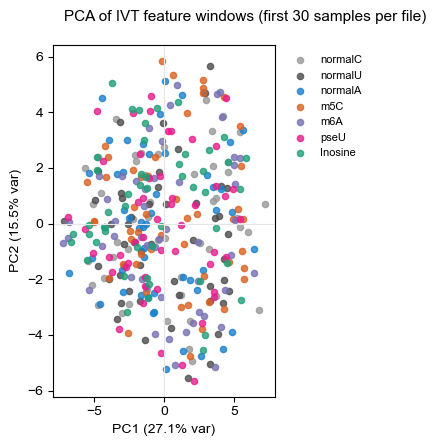

In [116]:
pca_plot_ivt_features()
